In [1]:
import numpy as np
from matplotlib import pyplot as plt
import csv

%matplotlib inline

import xarray as xr
import lib_ecofun as lef
from importlib import reload
reload(lef)
from scipy.optimize import curve_fit, minimize

# Test: adding a public investment to the energy infrastructure

In [ ]:
fcu = 0.8
inicond = lef.inicond_yr(2000)
inicond['Kf_ini'] = inicond['Kf_ini']*lef.fossil_capacity_util/fcu

obs = dict()
obs['Ig_ratio'] = lef.Ig_obs/(lef.Ig_obs+lef.If_obs) # considering only investment in power generation capacity (no grids, storage, EVs, ...)
obs['Eg_ratio'] = lef.Eg_ratio

E_obs = xr.load_dataarray('Etot_hist_1965-2022.nc')
E_obs /= E_obs.sel(year = 2000)
obs['E'] = E_obs

In [12]:
parnames = ['growth', 'beta_0', 'r_inv', 'a', 'delta_sig']
initial_guess = [0.02, 0.2, 0.1, 1., 0.7]#, 1.]
bounds = [(0.001, 0.03), (-0.5, 0.5), (0.01, 0.4), (0.5, 1.5), (0.01, 2.)]#, (0.5, 1.5)]

year_ini = 2000

params = lef.default_params.copy()
print(params)
print('-------------')

# for par, val in zip(parnames, result.x):
#     print(par, val)

# verbose = True
# all_green = False
# I_weight = 1.
# result = minimize(lef.cost_function, initial_guess, bounds = bounds, args = (parnames, params, year_ini, inicond, verbose, all_green, I_weight, obs), tol = 1e-10)
# print(result)

{'growth': 0.01, 'eps': 1, 'a': 1, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.1, 'beta_0': 0.2, 'delta_sig': 0.5, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
-------------


## 1. Emergent scenario with market only (historical fit of part I)

params:  {'growth': 0.0209418, 'eps': 1, 'a': 0.94184146, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.11684169, 'beta_0': -0.28310971, 'delta_sig': 0.47990969, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
check:       0.07     -0.44      0.07      0.93      0.01      0.37      0.00      0.04
params:  {'growth': 0.0209418, 'eps': 1, 'a': 0.94184146, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.11684169, 'beta_0': -0.28310971, 'delta_sig': 0.47990969, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
check:       0.07     -0.42      0.08      0.95      0.01      0.38      0.00      0.04
params:  {'growth': 0.0209418, 'eps': 1, 'a': 0.94184146, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.11684169, 'beta_0': -0.28310971, 'delta_sig': 0.47990969, 'delta_g': 0.01, 'delta_f

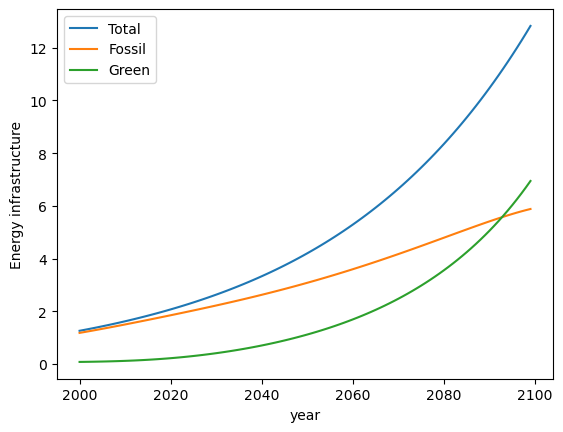

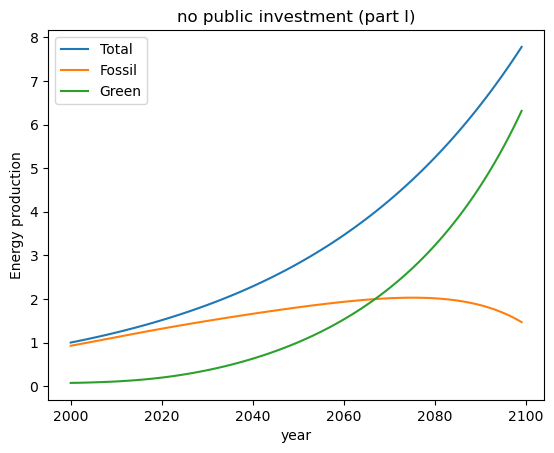

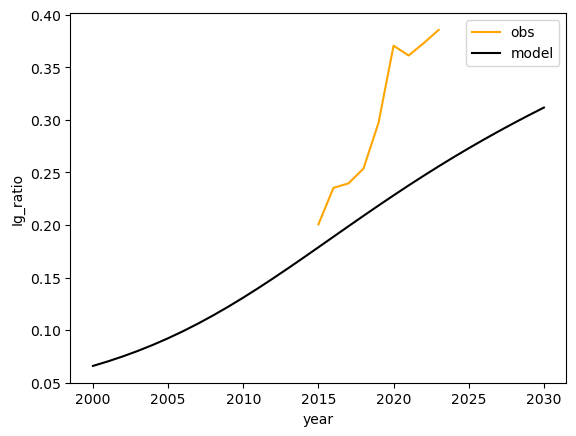

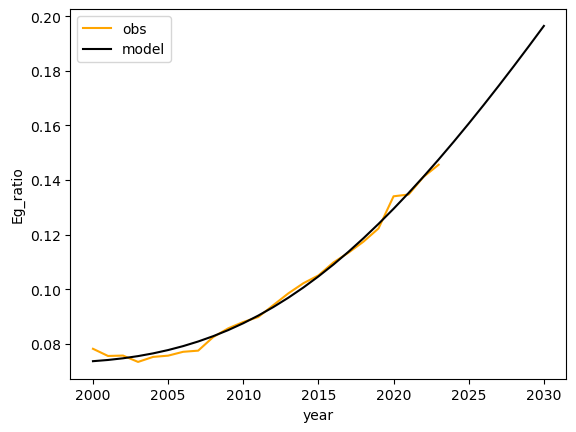

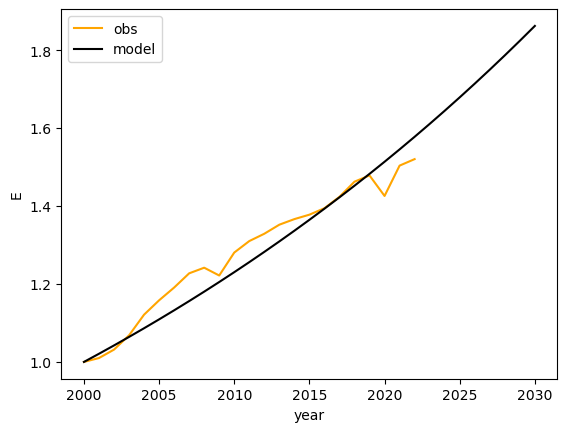

In [36]:
year_ini = 2000

params = lef.default_params.copy()

params_fit = [0.0209418 , -0.28310971,  0.11684169,  0.94184146,  0.47990969]

for par, parval in zip(parnames, params_fit):
    params[par] = parval

resu_onlymarket = lef.run_model(inicond = inicond, params = params, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini)
fig1, fig2 = lef.plot_resu(resu_onlymarket, year_ini = year_ini)
plt.title(r'no public investment (part I)')
fig2.savefig('pubscen_onlymarket.pdf')
figs_obs = lef.plot_resuvsobs_ds(resu_onlymarket, obs)

yini = year_ini

cost = lef.costfun(resu_onlymarket, obs)#, weights = weights)
print(cost)

## 2. Scenario with public investment: state investing a share of GDP in energy. A fraction $\mu$ goes to green, (1-$\mu$) to fossil

In [19]:
from importlib import reload
reload(lef)

<module 'lib_ecofun' from '/home/fedef/Research/abstractsepapers/papers/DREAM/codes/lib_ecofun.py'>

### $\mu$ growing from 0 to 100% in one century

params:  {'growth': 0.0209418, 'eps': 1, 'a': 0.94184146, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.11684169, 'beta_0': -0.28310971, 'delta_sig': 0.47990969, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
check:       0.07     -0.44      0.07      0.93      0.01      0.37      0.00      0.04
params:  {'growth': 0.0209418, 'eps': 1, 'a': 0.94184146, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.11684169, 'beta_0': -0.28310971, 'delta_sig': 0.47990969, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
check:       0.09     -0.36      0.09      0.94      0.01      0.37      0.00      0.04
params:  {'growth': 0.0209418, 'eps': 1, 'a': 0.94184146, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.11684169, 'beta_0': -0.28310971, 'delta_sig': 0.47990969, 'delta_g': 0.01, 'delta_f

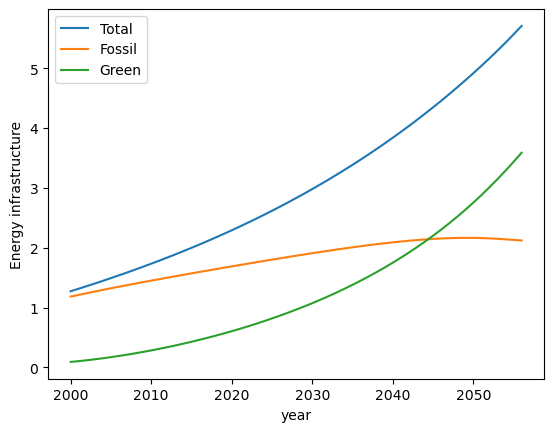

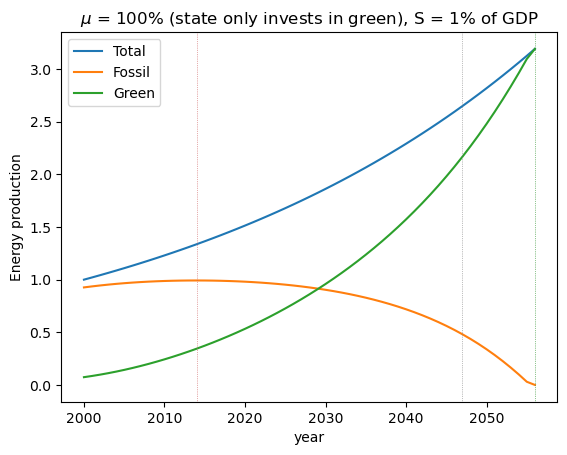

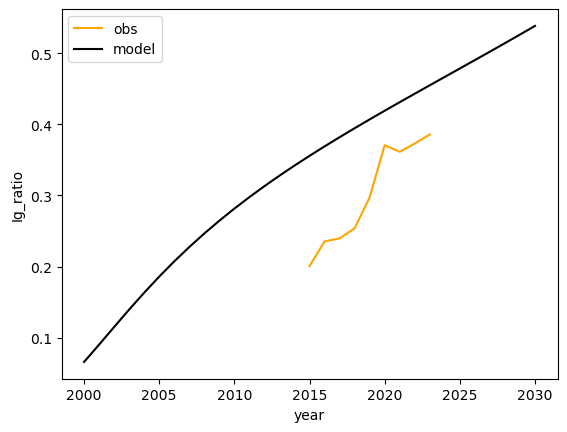

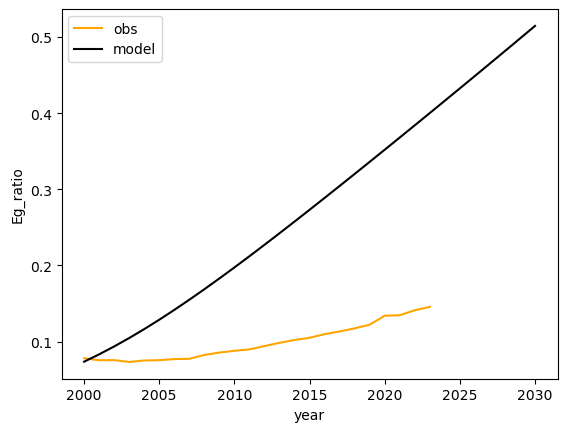

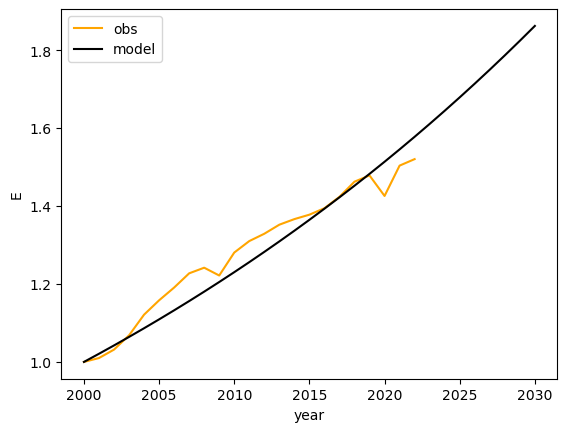

In [31]:
arr = np.linspace(1., 1., 100)
mu_scen = xr.DataArray(arr, dims = ('year'), coords = {'year': np.arange(year_ini, 2100)})

params['r_inv_state'] = 0.01 # 1% of GDP in public energy investment

resu_linear_to_green = lef.run_model(inicond = inicond, params = params, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment = True, mu_state_scenario = mu_scen)
fig1, fig2 = lef.plot_resu(resu_linear_to_green, year_ini = year_ini)
plt.title(r'$\mu$ = 100% (state only invests in green), S = 1% of GDP')
fig2.savefig('pubscen_mu100_s1.pdf')
figs_obs = lef.plot_resuvsobs_ds(resu_linear_to_green, obs)

params:  {'growth': 0.0209418, 'eps': 1, 'a': 0.94184146, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.11684169, 'beta_0': -0.28310971, 'delta_sig': 0.47990969, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
check:       0.07     -0.44      0.07      0.93      0.01      0.37      0.00      0.04
params:  {'growth': 0.0209418, 'eps': 1, 'a': 0.94184146, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.11684169, 'beta_0': -0.28310971, 'delta_sig': 0.47990969, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
check:       0.07     -0.41      0.08      0.94      0.01      0.38      0.00      0.04
params:  {'growth': 0.0209418, 'eps': 1, 'a': 0.94184146, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.11684169, 'beta_0': -0.28310971, 'delta_sig': 0.47990969, 'delta_g': 0.01, 'delta_f

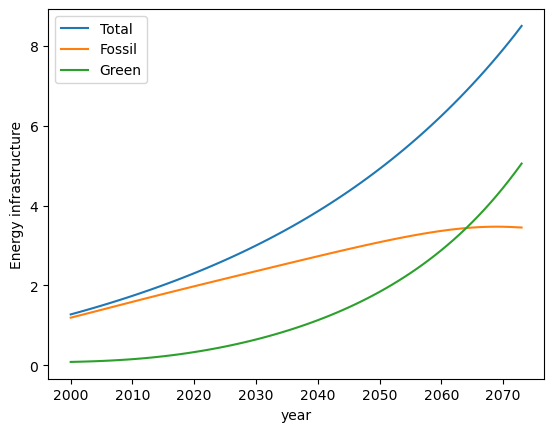

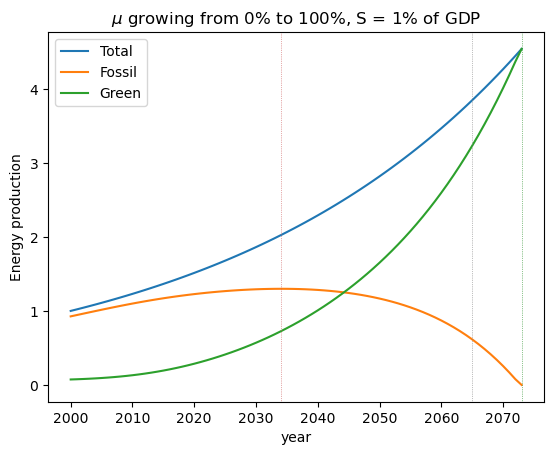

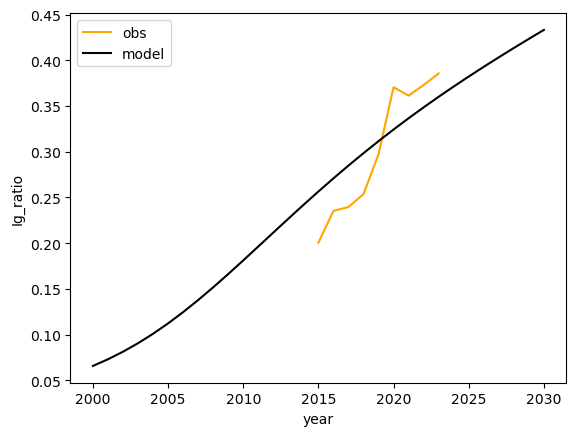

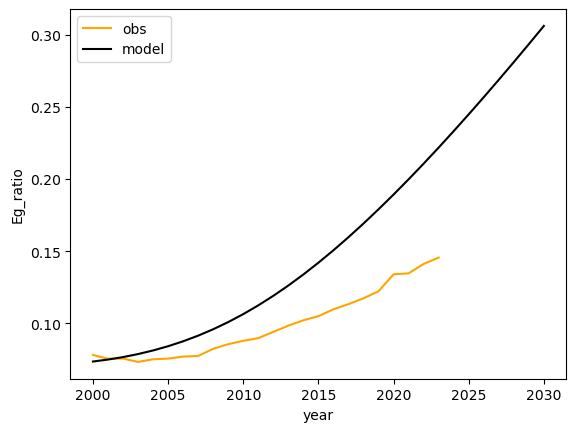

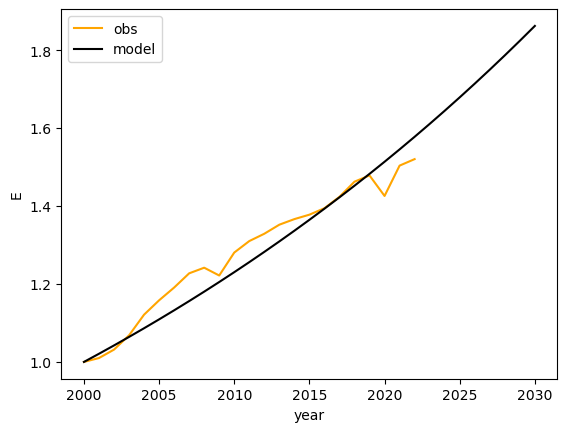

In [32]:
arr = np.linspace(0.1, 1., 100)
mu_scen = xr.DataArray(arr, dims = ('year'), coords = {'year': np.arange(year_ini, 2100)})

params['r_inv_state'] = 0.01 # 1% of GDP in public energy investment

resu_linear_to_green = lef.run_model(inicond = inicond, params = params, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment = True, mu_state_scenario = mu_scen)
fig1, fig2 = lef.plot_resu(resu_linear_to_green, year_ini = year_ini)
plt.title(r'$\mu$ growing from 0% to 100%, S = 1% of GDP')
fig2.savefig('pubscen_mu0-100_s1.pdf')
figs_obs = lef.plot_resuvsobs_ds(resu_linear_to_green, obs)

### scenario with very low $\mu$

params:  {'growth': 0.0209418, 'eps': 1, 'a': 0.94184146, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.11684169, 'beta_0': -0.28310971, 'delta_sig': 0.47990969, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
check:       0.07     -0.44      0.07      0.93      0.01      0.37      0.00      0.04
params:  {'growth': 0.0209418, 'eps': 1, 'a': 0.94184146, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.11684169, 'beta_0': -0.28310971, 'delta_sig': 0.47990969, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
check:       0.07     -0.42      0.08      0.95      0.01      0.38      0.00      0.04
params:  {'growth': 0.0209418, 'eps': 1, 'a': 0.94184146, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.11684169, 'beta_0': -0.28310971, 'delta_sig': 0.47990969, 'delta_g': 0.01, 'delta_f

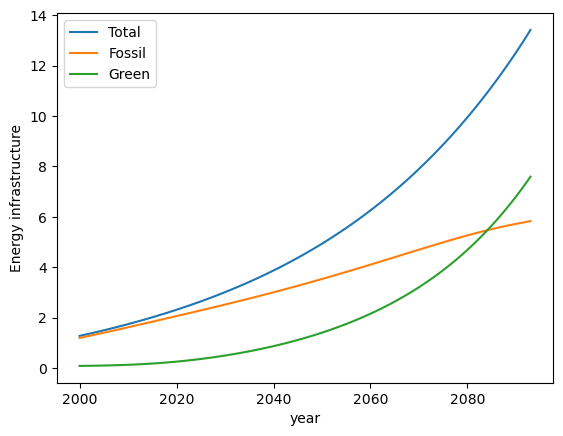

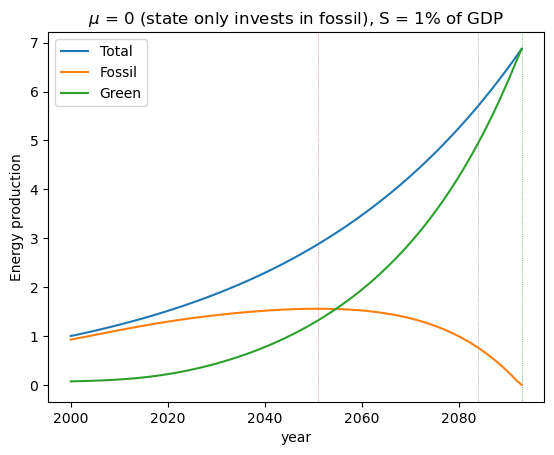

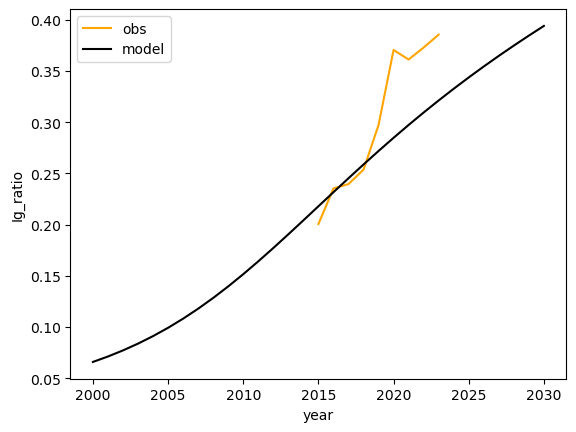

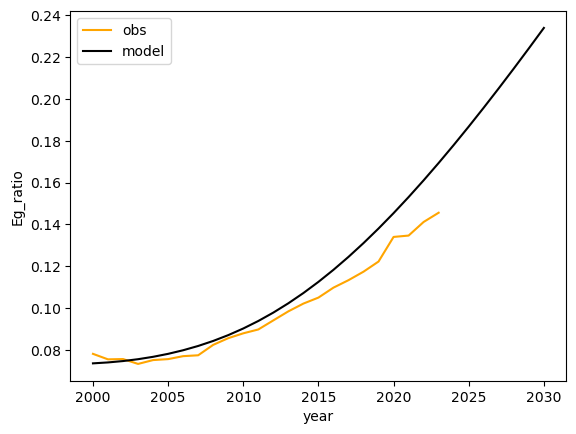

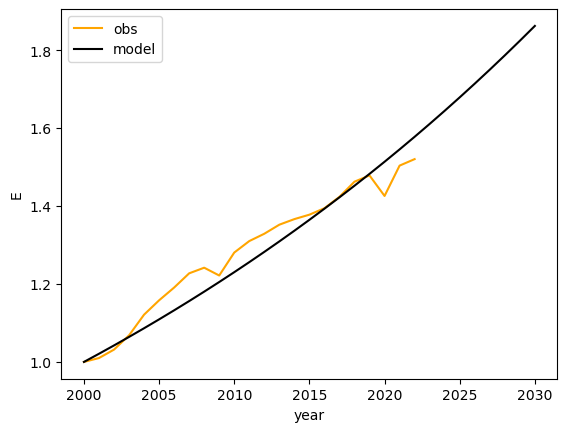

In [33]:
arr = np.linspace(0.0, 0.0, 100) # mu growing from 10% to 100% in one century
mu_scen = xr.DataArray(arr, dims = ('year'), coords = {'year': np.arange(year_ini, 2100)})

params['r_inv_state'] = 0.01 # 1% of GDP in public energy investment

resu_linear_to_green = lef.run_model(inicond = inicond, params = params, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment = True, mu_state_scenario = mu_scen)
fig1, fig2 = lef.plot_resu(resu_linear_to_green, year_ini = year_ini)
plt.title(r'$\mu$ = 0 (state only invests in fossil), S = 1% of GDP')
fig2.savefig('pubscen_mu0_s1.pdf')
figs_obs = lef.plot_resuvsobs_ds(resu_linear_to_green, obs)